In [1]:
import pandas as pd

## Data Munging

In [2]:
df = pd.read_csv("data_day2.csv")
# Sort to ensure chronological order
df = df.sort_values("recording_time_ns").reset_index(drop=True)

# Define the maximum expected gap between rows within the same experiment
# (e.g., 1e9 nanoseconds = 1 second)
threshold_ns = 1e9

# True where a new block starts, False otherwise
is_new_experiment = df["recording_time_ns"].diff() > threshold_ns

# Cumulative sum assigns a monotonically increasing integer to each contiguous block
df["experiment_id"] = is_new_experiment.cumsum()

# Split into a list of DataFrames
experiment_dfs = [group for _, group in df.groupby("experiment_id")]

In [3]:
for idx, idf in enumerate(experiment_dfs):
    idf.to_csv(f"day2/experiment{idx + 1}.csv")

In [4]:
experiment_idx = 2
experiment_data = df[df["experiment_id"] == experiment_idx]
experiment_data

,recording_time_ns,dt,wind_enabled,pos_x,pos_y,pos_z,pos_roll,pos_pitch,pos_yaw,targetpos_x,targetpos_y,targetpos_z,targetpos_yaw,control_vel_x,control_vel_y,control_vel_z,control_vel_yaw,experiment_id
383,1777300894777450486,1.777301e+09,False,-0.773390,1.615569,0.841583,-0.003154,0.096343,-0.152841,-2.0,0.0,2.0,0.0,-0.300000,-0.300000,0.300000,0.091705,2
384,1777300894896531669,1.191070e-01,False,-0.771980,1.619141,0.842924,-0.001209,0.095689,-0.150360,-2.0,0.0,2.0,0.0,-0.300000,-0.300000,0.300000,0.090216,2
385,1777300894977780238,8.116889e-02,False,-0.770041,1.622436,0.844197,0.001666,0.087098,-0.152496,-2.0,0.0,2.0,0.0,-0.300000,-0.300000,0.300000,0.091498,2
386,1777300895078410873,1.004167e-01,False,-0.768261,1.625863,0.845065,0.006596,0.086167,-0.154115,-2.0,0.0,2.0,0.0,-0.300000,-0.300000,0.300000,0.092469,2
387,1777300895178072996,9.927201e-02,False,-0.766282,1.628360,0.845962,0.006761,0.083247,-0.152090,-2.0,0.0,2.0,0.0,-0.300000,-0.300000,0.300000,0.091254,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,1777300927857682111,5.100250e-02,False,-2.657701,-0.720766,2.550634,-0.099245,-0.069421,1.828272,-3.0,-1.0,3.0,1.5,-0.067634,0.093857,0.269620,-0.196963,2
714,1777300927958489198,1.008744e-01,False,-2.692393,-0.742646,2.568975,-0.076231,-0.063828,1.823951,-3.0,-1.0,3.0,1.5,-0.066110,0.101173,0.258615,-0.194371,2
715,1777300928058290940,9.981728e-02,False,-2.724334,-0.759317,2.584035,-0.100219,-0.062927,1.816907,-3.0,-1.0,3.0,1.5,-0.074554,0.090284,0.249579,-0.190144,2
716,1777300928160108606,1.017513e-01,False,-2.752395,-0.774921,2.599021,-0.098761,-0.048213,1.814480,-3.0,-1.0,3.0,1.5,-0.070527,0.085367,0.240587,-0.188688,2


In [5]:
print(f"{1776697177697 / 0.02:.1e}")

8.9e+13


In [6]:
experiment_data["dt"]

383    1.777301e+09
384    1.191070e-01
385    8.116889e-02
386    1.004167e-01
387    9.927201e-02
           ...     
713    5.100250e-02
714    1.008744e-01
715    9.981728e-02
716    1.017513e-01
717    9.696388e-02
Name: dt, Length: 335, dtype: float64

## Trajectory Plot

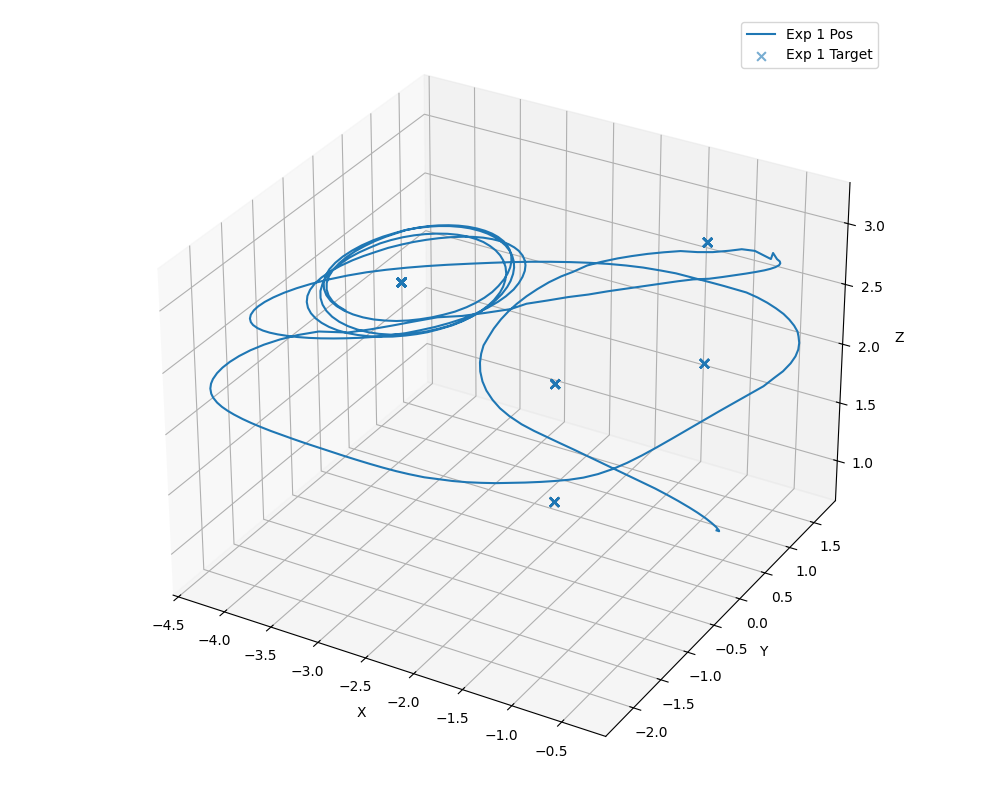

In [7]:
%matplotlib widget
import matplotlib.pyplot as plt


def plot_trajectories_3d(experiment_dfs):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, df in enumerate(experiment_dfs):
        line = ax.plot(df["pos_x"], df["pos_y"], df["pos_z"], label=f"Exp {i + 1} Pos")

        ax.scatter(
            df["targetpos_x"],
            df["targetpos_y"],
            df["targetpos_z"],
            label=f"Exp {i + 1} Target",
            color=line[0].get_color(),
            marker="x",
            s=40,
            alpha=0.6,
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_trajectories_3d(experiment_dfs[6:7])

In [ ]:
from matplotlib import animation


def save_rotating_trajectory(experiment_dfs, filename="trajectory.mp4"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, df in enumerate(experiment_dfs):
        line = ax.plot(df["pos_x"], df["pos_y"], df["pos_z"], label=f"Exp {i + 1} Pos")
        ax.scatter(
            df["targetpos_x"],
            df["targetpos_y"],
            df["targetpos_z"],
            label=f"Exp {i + 1} Target",
            color=line[0].get_color(),
            marker="x",
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    # ax.legend()
    plt.tight_layout()

    # Hide grid lines
    ax.grid(False)

    # Hide axes ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    # plt.axis("off")

    def update(frame):
        ax.view_init(elev=30, azim=frame)
        return (fig,)

    ani = animation.FuncAnimation(fig, update, frames=range(360))
    ani.save(filename, writer=animation.FFMpegWriter(fps=30))
    plt.close()


save_rotating_trajectory(experiment_dfs[6:7])

## Heatmap

In [ ]:
import numpy as np

tuning_df = pd.read_csv("./kalman_5x5.csv")
tuning_df = tuning_df[
    [
        "horizon",
        "delta_regularisation_strength",
        "avg_mean_position_error_m",
        "avg_position_error_variance_m2",
    ]
]
tuning_df["avg_position_error_std"] = np.sqrt(
    tuning_df["avg_position_error_variance_m2"]
)
tuning_df.drop(columns={"avg_position_error_variance_m2"}, inplace=True)
tuning_df.head()

,horizon,delta_regularisation_strength,avg_mean_position_error_m,avg_position_error_std
0,15,0.1,0.007837,0.002277
1,20,0.1,0.007921,0.002185
2,10,0.1,0.008919,0.002749
3,20,0.5,0.009321,0.002793
4,15,0.5,0.012266,0.003620


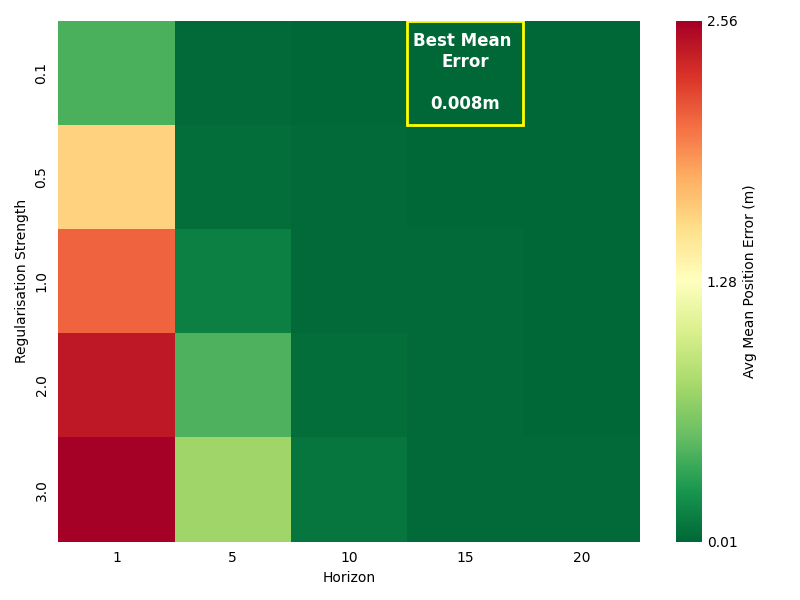

In [ ]:
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns

grid = tuning_df.pivot(
    index="delta_regularisation_strength",
    columns="horizon",
    values="avg_mean_position_error_m",
)

vmin, vmax = grid.values.min(), grid.values.max()
vmid = (vmin + vmax) / 2

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    grid,
    annot=False,
    cmap="RdYlGn_r",
    cbar_kws={"label": "Avg Mean Position Error (m)", "ticks": [vmin, vmid, vmax]},
)

# Format the 3 specific colourbar ticks
ax.tick_params(left=False, bottom=False)
ax.collections[0].colorbar.ax.tick_params(size=0)
ax.collections[0].colorbar.set_ticklabels([f"{vmin:.2f}", f"{vmid:.2f}", f"{vmax:.2f}"])

best_y_val, best_x_val = grid.stack().idxmin()
min_val = grid.loc[best_y_val, best_x_val]
y_idx = grid.index.get_loc(best_y_val)
x_idx = grid.columns.get_loc(best_x_val)

ax.add_patch(
    patches.Rectangle((x_idx, y_idx), 1, 1, fill=False, edgecolor="yellow", lw=2)
)

# Center text inside the winning cell
ax.text(
    x_idx + 0.5,
    y_idx + 0.5,
    f"Best Mean \nError\n\n{min_val:.3f}m",
    ha="center",
    va="center",
    color="white",
    weight="bold",
    fontsize=12,
)

plt.title("")
plt.xlabel("Horizon")
plt.ylabel("Regularisation Strength")
plt.tight_layout()
plt.savefig("tuning_heatmap.png")
plt.show()